# Multiple Testing Real Data Analysis & Plots

This notebook translates `real_data_analysis.R` and `plot_generator.R` from the follow-up paper "Multiple testing with anytime-valid Monte-Carlo p-values".
It analyzes real fMRI data and generates figures from simulation results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
from sequential_BH import sequential_BH, p_adjust_fdr

os.makedirs("results", exist_ok=True)

## 1. Real Data Analysis
The data needs to be downloaded from https://osf.io/8fsnx/ and placed in `model_fits/`.

In [2]:
# We mock the loading if the data isn't present to prevent errors
r2_perm = []
r2_true = []
data_available = True

for j in range(1, 9):
    try:
        data_perm = np.load(f"model_fits/S0{j}/all_fit_params_perm.npy", allow_pickle=True).item()
        data_true = np.load(f"model_fits/S0{j}/all_fit_params.npy", allow_pickle=True).item()
        r2_perm.append(data_perm['val_r2'])
        r2_true.append(data_true['val_r2'])
    except Exception as e:
        data_available = False
        break

if data_available:
    r2_perm = np.vstack(r2_perm)
    r2_true = np.concatenate(r2_true)

    M = len(r2_true)
    B = 1000
    alpha = 0.01

    peeking_times = list(range(1, B + 1))
    
    peeking_times_AMT = np.cumsum(np.concatenate(([10], 10 * np.cumprod(np.full(24, 1.1)))))
    peeking_times_AMT = np.concatenate((peeking_times_AMT, [1000]))

    results_bm = sequential_BH(r2_true, r2_perm, M, B, peeking_times, alpha, param_bm=0.6, method="bm")
    results_bc = sequential_BH(r2_true, r2_perm, M, B, peeking_times, alpha, param_bc=3, method="bc")
    results_agg = sequential_BH(r2_true, r2_perm, M, B, peeking_times, alpha, param_bc=1, method="bc")
    results_amt = sequential_BH(r2_true, r2_perm, M, B, peeking_times, alpha=(alpha - 0.001), param_amt=0.001, peeking_times_AMT=peeking_times_AMT, method="AMT")

    print("BM Rejection prop:", len(results_bm['rejects']) / M)
    print("BC Rejection prop:", len(results_bc['rejects']) / M)
    print("Agg Rejection prop:", len(results_agg['rejects']) / M)
    print("AMT Rejection prop:", len(results_amt['rejects']) / M)

    print("BM Mean stop:", np.mean(results_bm['stop']))
    print("BC Mean stop:", np.mean(results_bc['stop']))
    print("Agg Mean stop:", np.mean(results_agg['stop']))
    print("AMT Mean stop:", np.mean(results_amt['stop']))

    # Classical
    p_vals = (np.sum(r2_perm >= r2_true[:, None], axis=1) + 1) / (B + 1)
    p_vals_BH = p_adjust_fdr(p_vals)
    print("Classical Permutation BH prop <= 0.01:", np.mean(p_vals_BH <= 0.01))
else:
    print("Real data not found. Please download from https://osf.io/8fsnx/ into 'model_fits/' to run this cell.")

Real data not found. Please download from https://osf.io/8fsnx/ into 'model_fits/' to run this cell.


## 2. Generate Plots
We define functions to plot the worst case bounds and the results of the simulations (if they exist).

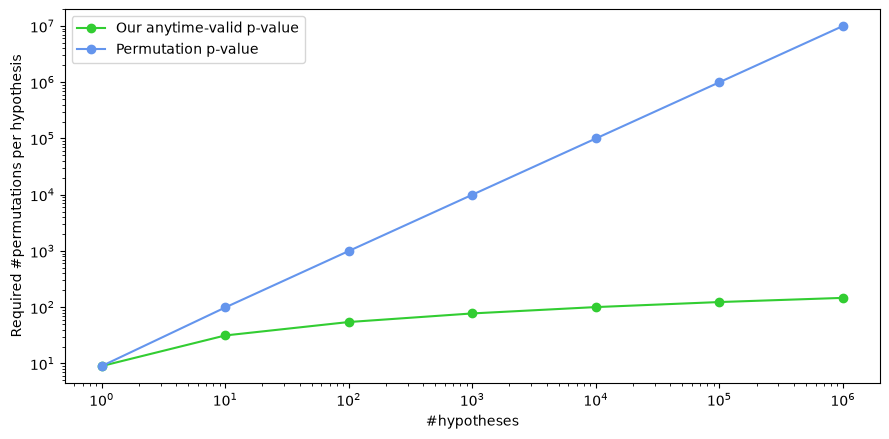

In [3]:
M_vals = np.array([1, 10, 100, 1000, 10000, 100000, 1000000])
alpha_val = 0.1
h = 1

def worst_samples_avBC(M):
    first_part = np.floor(h/alpha_val - 1)
    limit1 = int(np.floor(h/alpha_val) + 1)
    limit2 = int(np.ceil(M*h/alpha_val) - 1)
    if limit1 <= limit2:
        second_part = (h/alpha_val) * np.sum(1.0 / np.arange(limit1, limit2 + 1))
    else:
        second_part = 0
    return first_part + second_part

def worst_samples_perm(M):
    return np.ceil(M/alpha_val - 1)

avBC_vals = [worst_samples_avBC(m) for m in M_vals]
perm_vals = [worst_samples_perm(m) for m in M_vals]

plt.figure(figsize=(9, 4.5))
plt.plot(M_vals, avBC_vals, marker='o', color='limegreen', label='Our anytime-valid p-value')
plt.plot(M_vals, perm_vals, marker='o', color='cornflowerblue', label='Permutation p-value')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('#hypotheses')
plt.ylabel('Required #permutations per hypothesis')
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.savefig("results/Plot_worst_bounds.pdf")
plt.show()

For the rest of the plots, they require the `.pkl` files generated by `Multiple_testing_data_generator.ipynb`. 
Because the simulations are heavy, we provide a mock loading block. Once you run the generator, you can uncomment and adapt the visualization blocks.

In [4]:
print("To generate Figures for pis, alphas, mus, Ms, rhos, you must run the data generator notebook first.")

To generate Figures for pis, alphas, mus, Ms, rhos, you must run the data generator notebook first.
